In [1]:
import pandas as pd

In [2]:
last_review = pd.read_csv('sample_data/airbnb_last_review.csv')
price = pd.read_csv('sample_data/airbnb_price.csv')
room_type = pd.read_excel('sample_data/airbnb_room_type.xlsx')
# room_type

In [3]:
df1 = last_review.merge(price, on='listing_id')
df2 = df1.merge(room_type, on='listing_id')
df2

,listing_id,host_name,last_review,price,nbhood_full,description,room_type
0,2595,Jennifer,May 21 2019,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt
1,3831,LisaRoxanne,July 05 2019,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,Chris,June 22 2019,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,Shunichi,June 24 2019,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room
4,5238,Ben,June 09 2019,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt
...,...,...,...,...,...,...,...
25204,36425863,Rusaa,July 07 2019,129 dollars,"Manhattan, Upper East Side",Lovely Privet Bedroom with Privet Restroom,PRIVATE ROOM
25205,36427429,H Ai,July 07 2019,45 dollars,"Queens, Flushing",No.2 with queen size bed,PRIVATE ROOM
25206,36438336,Ben,July 07 2019,235 dollars,"Staten Island, Great Kills",Seas The Moment,Private room
25207,36442252,Blaine,July 07 2019,100 dollars,"Bronx, Mott Haven",1B-1B apartment near by Metro,Entire home/apt


**Description about the data set**

In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   host_name    25201 non-null  object
 2   last_review  25209 non-null  object
 3   price        25209 non-null  object
 4   nbhood_full  25209 non-null  object
 5   description  25199 non-null  object
 6   room_type    25209 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


In [5]:
df2.describe()

,listing_id
count,2.520900e+04
mean,2.068922e+07
std,1.102928e+07
min,2.595000e+03
25%,1.202273e+07
50%,2.234391e+07
75%,3.037669e+07
max,3.645581e+07


# **Determining the earliest and most recent review dates**

In [6]:
df2['last_review'] = pd.to_datetime(df2['last_review'],format='%B %d %Y')

In [7]:
df2['last_review']

,last_review
0,2019-05-21
1,2019-07-05
2,2019-06-22
3,2019-06-24
4,2019-06-09
...,...
25204,2019-07-07
25205,2019-07-07
25206,2019-07-07
25207,2019-07-07


In [8]:
print(f'Earliest review date: {df2["last_review"].min()}')
print(f'Most recent review date: {df2["last_review"].max()}')

Earliest review date: 2019-01-01 00:00:00
Most recent review date: 2019-07-09 00:00:00


Search for the early review Time in this group

In [9]:
def getEarlyReview(df2):
  # get early end time
  earlyReview = df2[df2['last_review'] == df2['last_review'].min()]
  return earlyReview

In [10]:
getEarlyReview(df2)

,listing_id,host_name,last_review,price,nbhood_full,description,room_type
14,8025,Lisel,2019-01-01,80 dollars,"Brooklyn, Park Slope",CBG Helps Haiti Room#2.5,PRIVATE ROOM
98,31902,Sunder,2019-01-01,77 dollars,"Brooklyn, Flatlands",Sanctuary in East Flatbush,Private room
326,160609,Ligia,2019-01-01,200 dollars,"Manhattan, Upper West Side",LOCATION LOCATION LOCATION UWS 60's,Entire home/apt
335,165461,Rahul,2019-01-01,75 dollars,"Manhattan, Morningside Heights",Couldn't Be Closer To Columbia Uni2,Private room
444,242643,Lauryn,2019-01-01,137 dollars,"Brooklyn, Williamsburg","BIG 1br, SLEEPS 4, dishwashr, TV",Entire home/apt
...,...,...,...,...,...,...,...
19667,30958853,Fnu,2019-01-01,32 dollars,"Brooklyn, Sunset Park","Cozy room,25 minutes to Manhattan",Private room
19776,31066679,Dj,2019-01-01,100 dollars,"Brooklyn, Bushwick",Happy place to be,Private room
19815,31098262,Kusum&Kannan,2019-01-01,250 dollars,"Manhattan, Chelsea",1 Bedroom/1 Bath Apt in Hudson Yards/Midtown West,Entire home/apt
19836,31113241,Hasan,2019-01-01,200 dollars,"Queens, Flushing","5 min walk to train,2 min walk to bus, most s...",Entire home/apt


Null values

In [11]:
df2.isna().sum()
## there is no null values in this data set .....

,0
listing_id,0
host_name,8
last_review,0
price,0
nbhood_full,0
description,10
room_type,0


In [12]:
df2.dropna(inplace=True)

In [20]:
df2.shape
# dropped the null valued rows because this is larger dataset and the dropping of the few columns does not affect the dataset perdomace....

(25191, 7)

# Finding how many listings are private rooms

In [13]:
df2['room_type']=df2['room_type'].str.lower()

In [14]:

# how many private rooms are in this dataset this manner ....
df2[df2['room_type']=='private room'].shape[0]

11342

# Finding the average price of listings

In [15]:
# type of the df2['price'] data set is object pandas series data type withi this.....
# so that we remove the dollars part from the price .....
df2['price']=df2['price'].str.replace('dollars','').astype('int32')

In [16]:

# mean of this data .... prices
df2['price'].mean()

141.8169981342543

## Room type with the price ....

In [17]:
import matplotlib.pyplot as plt

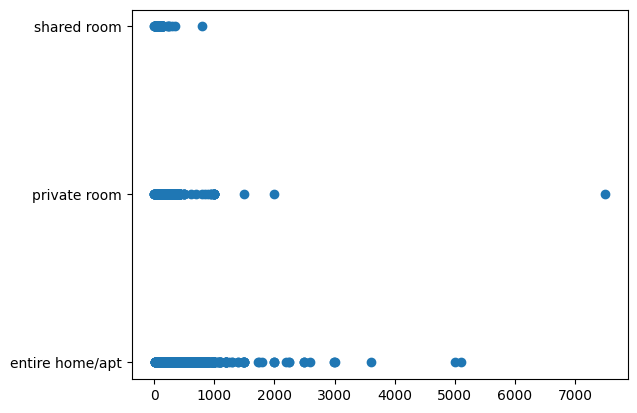

In [18]:
plt.scatter(df2['price'],df2['room_type'])
plt.show()